# Learning embeddings

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# for importing and working with texts
import re
import requests
import string

# pytorch stuff
import torch
import torch.nn as nn 
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary

# 1. Create a data loader to train a model

## Import text and create dictionary

In [2]:
# get raw text from internet
text = requests.get('https://www.gutenberg.org/files/35/35-0.txt').text
# character strings to replace with space
strings2replace = [ '\r\n\r\nâ\x80\x9c','â\x80\x9c','â\x80\x9d','\r\n','â\x80\x94','â\x80\x99','â\x80\x98','_', ]

# use regular expressions (re) to replace those strings with space
for str2match in strings2replace:
    text = re.compile(r'%s'%str2match).sub(' ', text)

# remove non-ASCII characters and numbers and make lower-case
text = re.sub(r'[^\x00-\x7F]+', ' ', text)
text = re.sub('\d+','',text).lower()

# split into words with >1 letters
words = re.split(f'[{string.punctuation}\s]+', text)
words = [item.strip() for item in words if item.strip()]
words = [item for item in words if len(item)>1]

# create the vocabualary
vocab = sorted(set(words))
n_words = len(words)
n_vocab = len(vocab)

# encoder/decoder look-up-tables (as python dictionaries)
word2idx = {word: i for i, word in enumerate(vocab)}
idx2word = {i: word for i, word in enumerate(vocab)}

# show a few keys in the dictionary
print(f'The book contains {n_words:,} words, {n_vocab:,} of which are unique and comprise the vocab.')
print(f'\n\nFirst 10 vocab words:\n',list(word2idx.keys())[:10])

<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:15: SyntaxWarning: invalid escape sequence '\s'
/var/folders/xb/2p09rqt55sj85gtsqtnpdnvh0000gp/T/ipykernel_7796/4043151826.py:12: SyntaxWarning: invalid escape sequence '\d'
  text = re.sub('\d+','',text).lower()
/var/folders/xb/2p09rqt55sj85gtsqtnpdnvh0000gp/T/ipykernel_7796/4043151826.py:15: SyntaxWarning: invalid escape sequence '\s'
  words = re.split(f'[{string.punctuation}\s]+', text)


The book contains 30,698 words, 4,589 of which are unique and comprise the vocab.


First 10 vocab words:
 ['abandon', 'abandoned', 'able', 'abnormally', 'abominable', 'abominations', 'about', 'above', 'abruptly', 'absence']


In [3]:
# parameters for dataset
context_length = 8
stride = 2 # skipping

# initialize
inputs = []
targets = []

# overlapping sequences of context_length
for i in range(0, n_words-context_length, stride):
    # get a few words
    in_seq = words[i: i+context_length]
    target_seq = words[i+1: i+1+context_length]
    # append to the lists
    inputs.append([word2idx[w] for w in in_seq])
    targets.append([word2idx[w] for w in target_seq])

print(inputs[123])
print(targets[123])

[1342, 4304, 4119, 342, 4296, 3388, 1474, 131]
[4304, 4119, 342, 4296, 3388, 1474, 131, 209]


In [4]:
# a closer look:
print("Inputs: ", inputs[4])
print("Targets:", targets[4])
print("")
print("Inputs: ", inputs[5])
print("Targets:", targets[5])
# this is what we need although we need it in torch Dataset/DataLoader format

Inputs:  [2416, 131, 2172, 506, 4451, 783, 2167, 2005]
Targets: [131, 2172, 506, 4451, 783, 2167, 2005, 4042]

Inputs:  [2172, 506, 4451, 783, 2167, 2005, 4042, 2416]
Targets: [506, 4451, 783, 2167, 2005, 4042, 2416, 2006]


In [5]:
# we need each list to be a tensor
torch.tensor(inputs[4])

tensor([2416,  131, 2172,  506, 4451,  783, 2167, 2005])

## Create a class for a dataset object

In [6]:
# create a class for a dataset
class WordDataset(Dataset):
    def __init__(self, text, word2idx, context_length=8, stride=4) -> None:
        # initialize
        self.inputs = []
        self.targets = []
        self.word2idx = word2idx # stored locally in the object

        # overlapping sequences of context_length
        for i in range(0, len(text)-context_length, stride):
            # get a few words
            in_seq = text[i: i+context_length]
            targ_seq = text[i+1: i+1+context_length]

            # append to the lists
            self.inputs.append(torch.tensor([word2idx[w] for w in in_seq]))
            self.targets.append(torch.tensor([word2idx[w] for w in targ_seq]))
    
    def __len__(self):
        return len(self.inputs)
    
    def __getitem__(self, index):
        return self.inputs[index], self.targets[index]

# create an instance!
context_length = 6
stride = 3 # skipping over tokens
text_dataset = WordDataset(words, word2idx, context_length, stride)

text_dataset[4]

(tensor([4451,  783, 2167, 2005, 4042, 2416]),
 tensor([ 783, 2167, 2005, 4042, 2416, 2006]))

## a dataloader for training

In [7]:
# also need a dataloader
dataloader = DataLoader(
    text_dataset,
    batch_size=32, # 2 for looking; 32 for training
    shuffle=True,
    drop_last=True
)


In [8]:

# lets have a look at the indices
X, y = next(iter(dataloader))
print("Inputs:")
print(X), print("")

print("Targets:")
print(y), print("\n\n\n")

# and the words
print("Inputs in words (first batch):")
print([idx2word[item.item()] for item in X[0]])
print("")

print("Targets in words (first batch):")
print([idx2word[item.item()] for item in y[0]])

Inputs:
tensor([[2400, 2186, 1815, 2651, 2722, 4119],
        [3422, 2791, 2041, 2608, 2518, 3110],
        [2442,  470, 1122,  501, 3712, 3831],
        [4428, 3169, 4042, 4529, 4296, 4042],
        [3911, 2731,  905,  137, 2339, 4408],
        [2740, 4042, 2778, 3581, 4058, 1815],
        [ 919, 2731, 4429, 1349, 1606, 4050],
        [4581,  339, 4295, 4119, 2435, 3388],
        [1868, 1737, 1594, 2163, 2742, 2731],
        [1043,  341, 4119, 3460, 4042, 2572],
        [3404, 2698,  137, 4047,  459,  639],
        [2347,  795, 1173, 2608, 4109, 2041],
        [3623, 2731, 4042, 2944, 4073, 2822],
        [ 137, 4439, 4546, 3503, 2569,  460],
        [4119, 1553, 2470, 1305,  137, 2740],
        [  36, 2608, 2518, 1572, 2553, 1453],
        [4572, 2208, 4051, 1815,  339, 2669],
        [4042, 2368, 2887,  312, 2041, 3517],
        [1703,  519, 4295, 2783, 2731,  131],
        [4058, 1815, 1011, 1572, 4042, 2061],
        [4260, 1793,  501, 4042, 2515, 4426],
        [3658,  320, 4042,

# 2. Build a model to learn the embeddings

In [9]:
np.logspace(np.log10(1000), np.log10(100000), 23)

array([  1000.        ,   1232.84673944,   1519.91108295,   1873.81742286,
         2310.12970008,   2848.03586844,   3511.19173422,   4328.76128108,
         5336.69923121,   6579.33224658,   8111.3083079 ,  10000.        ,
        12328.46739442,  15199.11082953,  18738.1742286 ,  23101.29700083,
        28480.35868436,  35111.91734215,  43287.61281083,  53366.99231206,
        65793.32246576,  81113.08307897, 100000.        ])

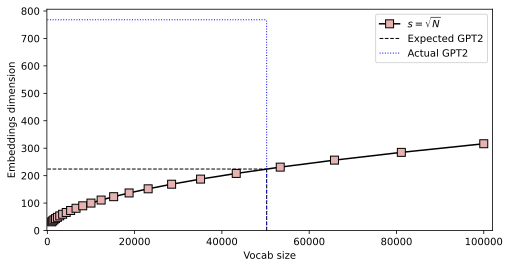

In [10]:
# exploring dimensionality based on vocab size

# vocab sizes
N = np.logspace(np.log10(1000), np.log10(100000), 23)

# heuristic for non-LLM models like Word2Vec or GloVe:
embdim = np.sqrt(N)

# parameters for GPT2
gpt2dims = [50257, 768]

plt.figure(figsize=(8,4))

# heuristic line
plt.plot(N, embdim, 'ks-', markersize=8, markerfacecolor=[.9,.7,.7], label=r'$s = \sqrt{N}$')

# expected embedding dim for GPT2
plt.plot([gpt2dims[0],gpt2dims[0]], 
         [0,np.sqrt(gpt2dims[0])], 
         'k--', 
         linewidth=1, 
         label='Expected GPT2')
plt.plot([0,gpt2dims[0]], 
         [np.sqrt(gpt2dims[0]),
          np.sqrt(gpt2dims[0])],
          'k--',
          linewidth=1)

# actual GPT2 embedding
plt.plot([gpt2dims[0],gpt2dims[0]],
         [0,gpt2dims[1]],
         'b:',
         linewidth=1,
         label='Actual GPT2')
plt.plot([0,gpt2dims[0]],
         [gpt2dims[1],gpt2dims[1]],
         'b:',
         linewidth=1)

plt.gca().set(xlabel="Vocab size",
              ylabel="Embeddings dimension",
              xlim=[-100,N[-1]+2000],
              ylim=[0,None])

plt.legend()
plt.show()

## Create and explore an embedding layer

In [11]:
# dimensionality of embedding space (arbitrarily set to 100)
embedding_dimension = 100

# create a random embedding 
embedding_layer = nn.Embedding(n_vocab, embedding_dimension)

# let's see its size
embedding_layer.weight.shape

torch.Size([4589, 100])

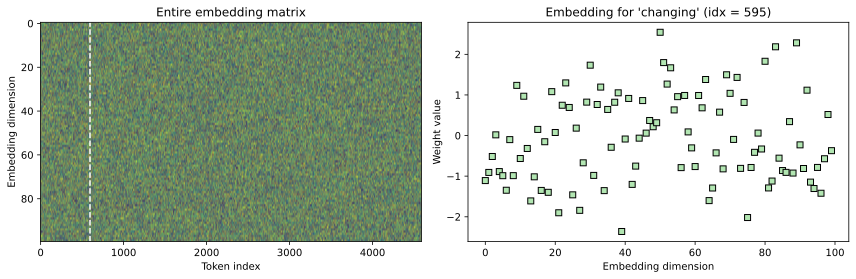

In [12]:
# what does it look like?

_, axs = plt.subplots(1,2,figsize=(12,4))
axs[0].imshow(embedding_layer.weight.detach().T, aspect='auto', vmin=-1, vmax=1)
axs[0].set(ylabel="Embedding dimension",
           xlabel="Token index",
           title="Entire embedding matrix")

# pick a word at random
random_word = np.random.choice(vocab)

# plot its embedding
axs[1].plot(embedding_layer.weight.detach()[word2idx[random_word],:], 'ks', markerfacecolor=[.7,.9,.7])
axs[0].axvline(word2idx[random_word], color='w', linestyle='--')
axs[1].set(xlabel="Embedding dimension",
           ylabel="Weight value",
           title=f"Embedding for '{random_word}' (idx = {word2idx[random_word]})")

plt.tight_layout()
plt.show()

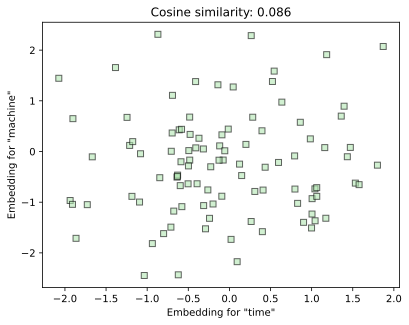

In [13]:
# embeddings for closely related words
word1 = 'time'
word2 = 'machine'

# their embeddings
embed1 = embedding_layer.weight.detach()[word2idx[word1],:]
embed2 = embedding_layer.weight.detach()[word2idx[word2],:]

# cosine similiarity between them
cosSim = torch.dot(embed1,embed2)/(torch.norm(embed1)*torch.norm(embed2))

# vizualize
plt.plot(embed1, embed2, 'ks', markerfacecolor=[.7,.9,.7], alpha=.6)
plt.gca().set(xlabel=f'Embedding for "{word1}"',
              ylabel=f'Embedding for "{word2}"',
              title=f'Cosine similarity: {cosSim:.3f}')
plt.show()

## Build the model

In [14]:
class EmbeddingModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, context_size):
        super(EmbeddingModel, self).__init__()

        # embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # linear layers
        self.linear1 = nn.Linear(context_size * embedding_dim, 128)
        self.linear2 = nn.Linear(128, vocab_size)
    
    def forward(self, inputs):
        # extract and flatten embeddings
        # [batch_size, context_size * embedding_dim]
        embeds = self.embedding(inputs).view(inputs.shape[0], -1)
        # fully connected layers
        out = F.relu(self.linear1(embeds))
        out = self.linear2(out)
        # log softmax for classification
        # (note: NLLLoss expects logprobs as inputs)
        log_probs = F.log_softmax(out, dim=1)
        return log_probs
    
# create a model instance
model = EmbeddingModel(vocab_size=n_vocab,
                       embedding_dim=embedding_dimension,
                       context_size=context_length)
print(model)

# apply Xavier weight distribution
for param in model.parameters():
    if param.dim()>1: # also excludes biases
        nn.init.xavier_normal_(param)

EmbeddingModel(
  (embedding): Embedding(4589, 100)
  (linear1): Linear(in_features=600, out_features=128, bias=True)
  (linear2): Linear(in_features=128, out_features=4589, bias=True)
)


In [15]:
# let's test the model
X, y = next(iter(dataloader))
model_out = model(X)

print('Input to model:')
print(X), print('')

print(f'Output from model (size: {list(model_out.detach().shape)}):')
print(model_out)

Input to model:
tensor([[2451, 2731, 3348, 4408, 2590, 3665],
        [2186, 3520, 2188, 4119, 2470, 4041],
        [1791, 2628, 4042, 3758,  137, 4446],
        [4064, 4576, 2728, 1275, 1599, 1419],
        [1815, 2669,  796,  636, 2041, 4042],
        [1541, 4296, 4042, 2368, 3987, 4047],
        [1795, 2927, 2731,  644, 2744, 1561],
        [4549, 4581, 2347, 4119, 3460, 4042],
        [1815,   99, 1022, 2041, 4042, 4109],
        [2685, 2638, 3267, 1572,  131, 1964],
        [2041, 4042, 1258, 4042,  293,  353],
        [4064, 1815, 1344, 1838, 4042,  472],
        [2783, 2731, 4073,   77, 2731, 2781],
        [2608,  266, 4408, 4042, 3026, 2731],
        [ 838,  911,  506, 4133, 1423, 1572],
        [2608, 1385, 4042,   88, 4408, 1645],
        [2186, 4467, 4428, 1906,  125, 4042],
        [3491, 2704, 3248, 4042, 3091, 2469],
        [1104, 4510, 2608, 1831,  255, 4042],
        [ 829, 2780, 3303, 1111, 2243, 2003],
        [4077, 2731,  899, 1815, 1935, 1584],
        [  71, 252

In [16]:
# log soft-max output:
print(model_out.detach()[0])
print("")

# shouldn't the sum be 1?
print(f'Log softmax sum = {model_out.detach()[0].sum():.3f}')

# ah, it's *log* softmax :D
print(f'exp(log(softmax)) sum = {torch.exp(model_out.detach()[0]).sum():.3f}')

tensor([-8.3710, -8.3651, -8.3611,  ..., -8.4955, -8.4152, -8.5022])

Log softmax sum = -38697.867
exp(log(softmax)) sum = 1.000


In [17]:
# find the word with the highest probability
print('Model input:')
print([idx2word[w.item()] for w in X[0]])
print('')

print('Model output:')
print(idx2word[model_out[0].argmax().item()])

Model input:
['mass', 'of', 'rock', 'was', 'moving', 'slowly']

Model output:
hopelessly


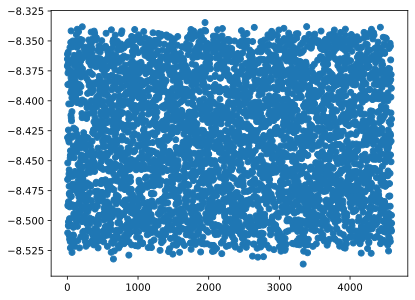

In [18]:
plt.plot(model_out[0].detach(), 'o');

## Have the model generate text

In [19]:
# grab some data from the loader
X,y = next(iter(dataloader))

print('First input:')
print(' '.join([idx2word[w.item()] for w in X[0]]))
print('\nSubsequent inputs:')

# text generation
for _ in range(context_length):
    # get output for this input
    Y = model(X)

    # pick the most likely next word
    next_word = Y[0].argmax().item()

    # create new input for the next iteration (word)
    X[0] = torch.concatenate((X[0][1:], torch.tensor([next_word])))

    # print out the generated text so far
    print(' '.join([idx2word[w.item()] for w in X[0]]))

First input:
full of such litter thus loaded

Subsequent inputs:
of such litter thus loaded grooves
such litter thus loaded grooves gunpowder
litter thus loaded grooves gunpowder arising
thus loaded grooves gunpowder arising helpful
loaded grooves gunpowder arising helpful hollowness
grooves gunpowder arising helpful hollowness relieve


## How big is our model?

In [20]:
# summary of model and parameters
summary(model, input_data=X, col_names=['input_size','output_size','num_params'])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
EmbeddingModel                           [32, 6]                   [32, 4589]                --
├─Embedding: 1-1                         [32, 6]                   [32, 6, 100]              458,900
├─Linear: 1-2                            [32, 600]                 [32, 128]                 76,928
├─Linear: 1-3                            [32, 128]                 [32, 4589]                591,981
Total params: 1,127,809
Trainable params: 1,127,809
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 36.09
Input size (MB): 0.00
Forward/backward pass size (MB): 1.36
Params size (MB): 4.51
Estimated Total Size (MB): 5.87

# 3. Train and evaluate the model

In [21]:
# use GPU if available for speed
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [22]:
# create a fresh model instance
model = EmbeddingModel(vocab_size=n_vocab,
                       embedding_dim=embedding_dimension,
                       context_size=context_length)

# with Xavier weight distribution
for param in model.parameters():
    if param.dim()>1:
        nn.init.xavier_normal_(param)

# and move it to the device (GPU)
model = model.to(device)

In [23]:
# create the loss and optimizer function
loss_function = nn.NLLLoss().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=.001, weight_decay=.01)

In [24]:
# quick test for errors and sanity-check the output matrix sizes
X, y = next(iter(dataloader))
X, y = X.to(device), y.to(device)

# forward pass 
model_output = model(X)

# check the sizes
print(f'Model input is of size: {X.shape}')
print(f'Target output is of size: {y.shape}')
print(f'Model output is of size: {model_output.shape}')

# loss function
loss = loss_function(model_output, y[:,-1])
print('\nLoss:')
loss

Model input is of size: torch.Size([32, 6])
Target output is of size: torch.Size([32, 6])
Model output is of size: torch.Size([32, 4589])

Loss:


tensor(8.4323, grad_fn=<NllLossBackward0>)

In [25]:
# extract a copy of the pretrained embedding weights for comparison later
pretrained_embeddings = model.embedding.weight.detach().cpu().clone()

In [26]:
# reminder: use batchsize=32 in data loader

## now train the model

In [27]:
def train_the_model(model, num_epochs=25):
    # initialize losses
    total_loss = np.zeros(num_epochs)

    for epoch in range(num_epochs):
        # initialize
        epoch_loss = 0

        # loop over batches in the data loader
        for X, y in dataloader:
            # move data to (GPU)
            X, y = X.to(device), y.to(device)

            # clear previous gradients
            model.zero_grad()

            # forward pass
            log_probs = model(X)

            # calculate the losses from the final target word
            loss = loss_function(log_probs, y[:,-1])

            # backprop
            loss.backward()
            optimizer.step()

            # sum per-epoch losses
            epoch_loss += loss.item()

        total_loss[epoch] = epoch_loss / len(dataloader.dataset)

        # update our progress
        print(f'  Finished epoch {epoch+1} with loss {epoch_loss / len(dataloader.dataset):.4f}')
    
    # output the model and the losses
    return model, total_loss

  Finished epoch 1 with loss 0.2168
  Finished epoch 2 with loss 0.1880
  Finished epoch 3 with loss 0.1757
  Finished epoch 4 with loss 0.1652
  Finished epoch 5 with loss 0.1547
  Finished epoch 6 with loss 0.1434
  Finished epoch 7 with loss 0.1308
  Finished epoch 8 with loss 0.1162
  Finished epoch 9 with loss 0.1000
  Finished epoch 10 with loss 0.0818
  Finished epoch 11 with loss 0.0623
  Finished epoch 12 with loss 0.0424
  Finished epoch 13 with loss 0.0252
  Finished epoch 14 with loss 0.0132
  Finished epoch 15 with loss 0.0064
  Finished epoch 16 with loss 0.0032
  Finished epoch 17 with loss 0.0018
  Finished epoch 18 with loss 0.0011
  Finished epoch 19 with loss 0.0007
  Finished epoch 20 with loss 0.0006
  Finished epoch 21 with loss 0.0004
  Finished epoch 22 with loss 0.0004
  Finished epoch 23 with loss 0.0003
  Finished epoch 24 with loss 0.0003
  Finished epoch 25 with loss 0.0003


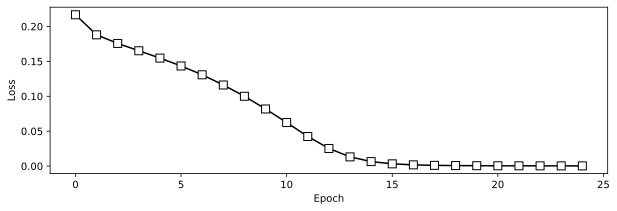

In [28]:
# train the model
model, total_loss = train_the_model(model) # using default 25 epochs

# plot the losses
plt.figure(figsize=(10,3))
plt.plot(total_loss, 'ks-', markerfacecolor='w', markersize=8)
plt.gca().set(xlabel='Epoch', ylabel='Loss')
plt.show()

In [29]:
# get a copy of the trained weights
postrained_embeddings = model.embedding.weight.detach().cpu().clone()

## distribution of embeddings

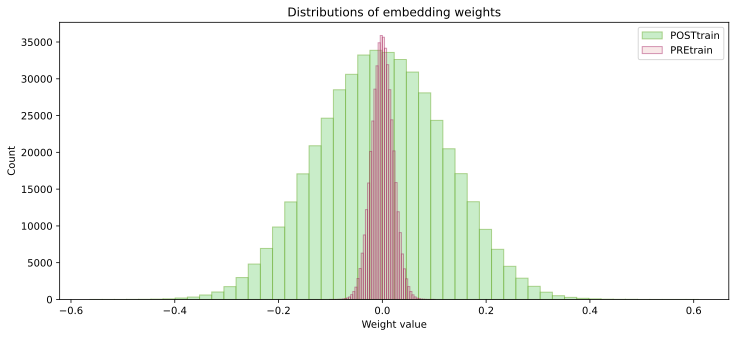

In [30]:
# histograms via numpy
yPre, xPre = np.histogram(pretrained_embeddings.flatten(), bins=50)
yPst, xPst = np.histogram(postrained_embeddings.flatten(), bins=50)

# recalculate x values as bin centers
xPre = (xPre[1:]+xPre[:-1]) / 2
xPst = (xPst[1:]+xPst[:-1]) / 2

# and plot
plt.figure(figsize=(12,5))
plt.bar(xPst,yPst,width=xPst[1]-xPst[0],color=[.7,.9,.7,.7],edgecolor=[.3,.6,0,.4],label='POSTtrain')
plt.bar(xPre,yPre,width=xPre[1]-xPre[0],color=[.9,.7,.7,.3],edgecolor=[.6,0,.3,.4],label='PREtrain')

plt.gca().set(xlabel='Weight value',ylabel='Count',title='Distributions of embedding weights')
plt.legend()
plt.show()

## Embedding vectors for a random word

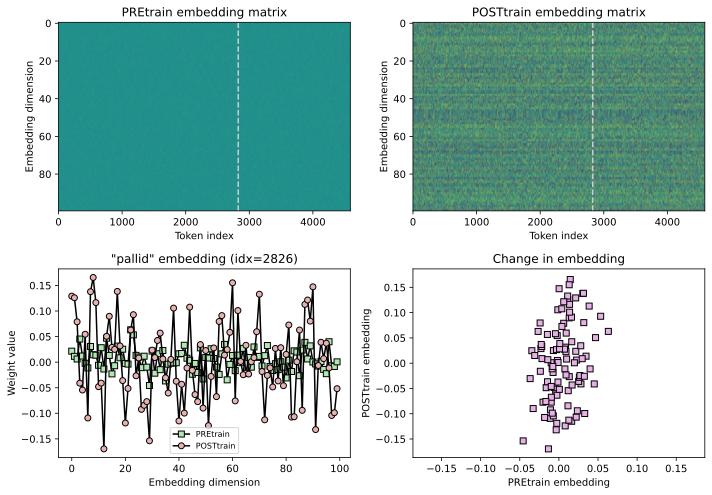

In [31]:
# pick a word at random
aRandomWord = np.random.choice(vocab)
randWord_idx = word2idx[aRandomWord]

# extract its embeddings vectors
pre_ev = pretrained_embeddings[randWord_idx,:]
pst_ev = postrained_embeddings[randWord_idx,:]



_,axs = plt.subplots(2,2,figsize=(10,7))

# the pretrainined embeddings
axs[0,0].imshow(pretrained_embeddings.T,aspect='auto',vmin=-.2,vmax=.2)
axs[0,0].set(ylabel='Embedding dimension',xlabel='Token index',title='PREtrain embedding matrix')

# the post-trainined embeddings
axs[0,1].imshow(postrained_embeddings.T,aspect='auto',vmin=-.2,vmax=.2)
axs[0,1].set(ylabel='Embedding dimension',xlabel='Token index',title='POSTtrain embedding matrix')


axs[0,0].axvline(randWord_idx,linestyle='--',color=[.8,.8,.8])
axs[0,1].axvline(randWord_idx,linestyle='--',color=[.8,.8,.8])

# plot its embedding
axs[1,0].plot(pre_ev,'ks-',markerfacecolor=[.7,.9,.7],label='PREtrain')
axs[1,0].plot(pst_ev,'ko-',markerfacecolor=[.9,.7,.7],label='POSTtrain')
axs[1,0].set(xlabel='Embedding dimension',ylabel='Weight value',title=f'"{aRandomWord}" embedding (idx={randWord_idx})')
axs[1,0].legend(fontsize=8)

# how it changed
axlim = max(abs(pre_ev).max(),abs(pst_ev).max()) * 1.1 # equal axis limits
axs[1,1].plot(pre_ev,pst_ev,'ks',markerfacecolor=[.9,.7,.9])
axs[1,1].set(xlim=[-axlim,axlim],ylim=[-axlim,axlim],xlabel='PREtrain embedding',
             ylabel='POSTtrain embedding',title='Change in embedding')

plt.tight_layout()
plt.show()

## Time Machine Embeddings

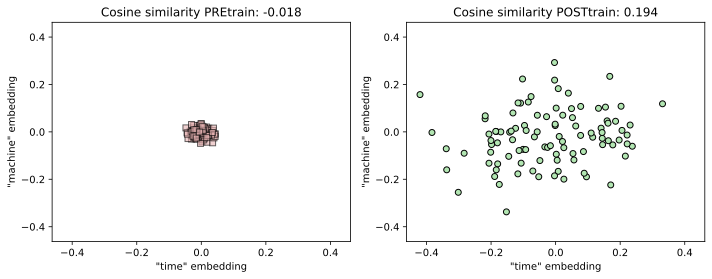

In [32]:
# embeddings for closely related words
word1 = 'time'
word2 = 'machine'

# their embeddings
embed1pre = pretrained_embeddings[word2idx[word1],:]
embed2pre = pretrained_embeddings[word2idx[word2],:]
embed1pst = postrained_embeddings[word2idx[word1],:]
embed2pst = postrained_embeddings[word2idx[word2],:]

# cosine similarity between them
cosSim_pre = F.cosine_similarity(embed1pre.unsqueeze(dim=0),embed2pre.view(1,-1))
cosSim_pst = nn.functional.cosine_similarity(embed1pst.unsqueeze(dim=0),embed2pst.view(1,-1))


# vizualize
_,axs = plt.subplots(1,2,figsize=(10,4))

axlim = torch.cat((abs(embed1pre),abs(embed2pre),abs(embed1pst),abs(embed2pst))).max() * 1.1
axs[0].plot(embed1pre,embed2pre,'ks',markerfacecolor=[.9,.7,.7],alpha=.6)
axs[0].set(xlim=[-axlim,axlim],ylim=[-axlim,axlim],xlabel=f'"{word1}" embedding',
           ylabel=f'"{word2}" embedding',title=f'Cosine similarity PREtrain: {cosSim_pre.item():.3f}')

axs[1].plot(embed1pst,embed2pst,'ko',markerfacecolor=[.7,.9,.7])
axs[1].set(xlim=[-axlim,axlim],ylim=[-axlim,axlim],xlabel=f'"{word1}" embedding',
           ylabel=f'"{word2}" embedding',title=f'Cosine similarity POSTtrain: {cosSim_pst.item():.3f}')

plt.tight_layout()
plt.show()